# Imports

In [1]:
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import scipy, scipy.stats

# Parameters

In [2]:
data_dirname = "../datasets/samson"
data_basename = "samson.npz"
results_basename = "samson_pixel_mask.npz"

colors = ["saddlebrown", "forestgreen", "royalblue"]

# Data Loading

In [3]:
filename = os.path.join(data_dirname, data_basename)

with np.load(filename) as npz_data:
    print(npz_data.keys())
    hsi_data = npz_data["hsi_data"]
    endmembers = npz_data["endmembers"]
    abundances = npz_data["abundances"]
    labels = npz_data["labels"]
    spectral_bands = npz_data["spectral_bands"]
    selected_bands = npz_data["selected_bands"]
    resolution = npz_data["resolution"]

print(f"      hsi_data: {hsi_data.shape}")
print(f"    endmembers: {endmembers.shape}")
print(f"    abundances: {abundances.shape}")
print(f"spectral_bands: {spectral_bands.shape}")
print(f"selected_bands: {selected_bands.shape}")
print(f"    resolution: {resolution}")
print(labels)

KeysView(NpzFile '../datasets/samson/samson.npz' with keys: hsi_data, endmembers, abundances, labels, spectral_bands...)
      hsi_data: (95, 95, 156)
    endmembers: (3, 156)
    abundances: (3, 95, 95)
spectral_bands: (157,)
selected_bands: (156,)
    resolution: nm
['Soil' 'Trees' 'Water']


# Pixel Filtering

In [4]:
filter_threshold = 0.9
pixel_mask = abundances.max(axis=0) >= filter_threshold

# Unfiltered Abundance Distributions

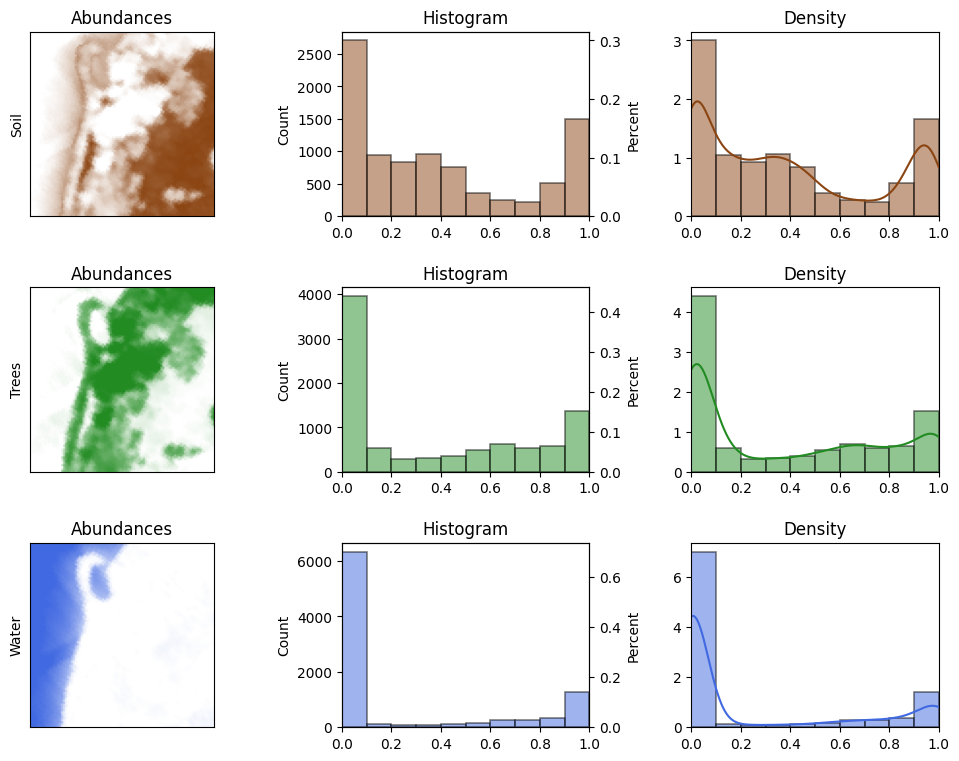

In [5]:
xx = np.linspace(start=0, stop=1, num=1000)

n_rows=len(endmembers)
n_cols=3

fig = plt.figure(constrained_layout=True, figsize=(8/2.5*n_cols,5/2*n_rows))
gs = mpl.gridspec.GridSpec(
    nrows=len(endmembers),
    ncols=n_cols,
    hspace=0.1,
    wspace=0.1,
    figure=fig
)
for ii,abundance_map in enumerate(abundances):
    abundance_values = abundance_map.flatten()
    cmap = mpl.colors.LinearSegmentedColormap.from_list(colors[ii], ["white", colors[ii]])

    ax = fig.add_subplot(gs[n_cols*ii+0])
    ax.imshow(abundance_map, cmap=cmap, vmin=0, vmax=1)
    ax.set_title("Abundances")
    ax.get_xaxis().set_visible(False)
    ax.set_ylabel(labels[ii])
    ax.axes.get_yaxis().set_ticks([])

    weights = np.ones(len(abundance_values)) / len(abundance_values)
    ax = fig.add_subplot(gs[n_cols*ii+1])
    ax.hist(abundance_values, bins=10, color=colors[ii], alpha=0.0)
    ax.set_ylabel("Count")
    ax = ax.twinx()
    ax.hist(abundance_values, bins=10, range=(0,1), weights=weights, color=colors[ii], edgecolor="black", linewidth=1.2, alpha=0.5)
    ax.set_xlim(0,1)
    ax.set_ylabel("Percent")
    ax.set_title("Histogram")
    
    kde = scipy.stats.gaussian_kde(abundance_values)
    ax = fig.add_subplot(gs[n_cols*ii+2])
    ax.hist(abundance_values, bins=10, range=(0,1), density=True, color=colors[ii], edgecolor="black", linewidth=1.2, alpha=0.5)
    ax.plot(xx, kde(xx), color=colors[ii])
    ax.set_xlim(0,1)
    ax.set_title("Density")
plt.show()

# Filtered Abundance Distributions

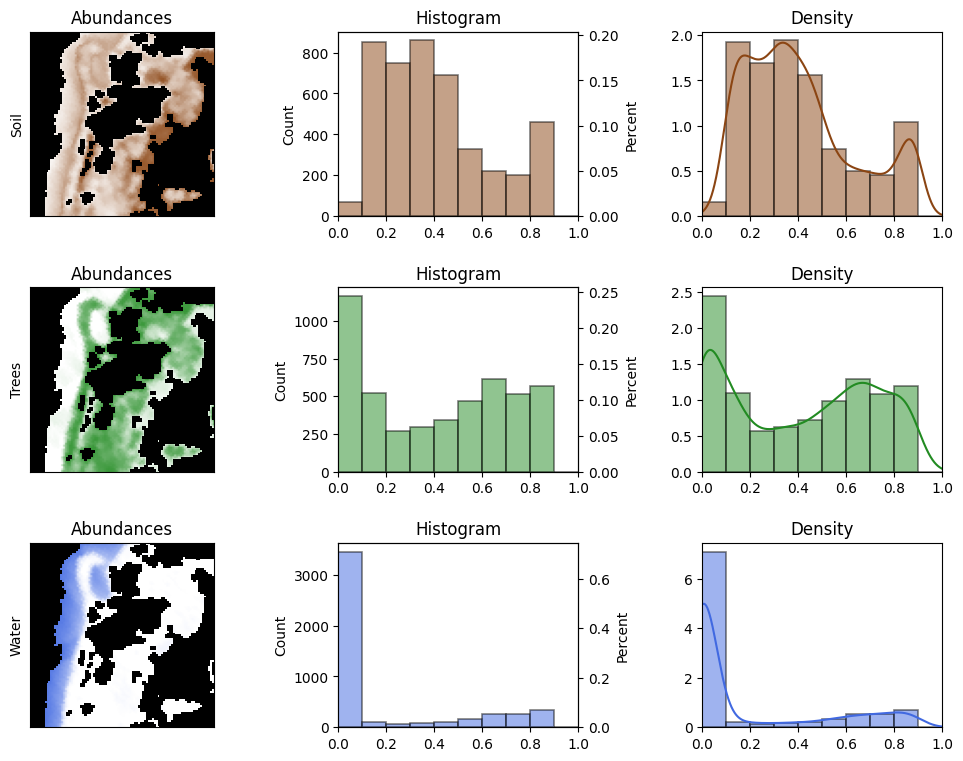

In [6]:
xx = np.linspace(start=0, stop=1, num=1000)

n_rows=len(endmembers)
n_cols=3

fig = plt.figure(constrained_layout=True, figsize=(8/2.5*n_cols,5/2*n_rows))
gs = mpl.gridspec.GridSpec(
    nrows=len(endmembers),
    ncols=n_cols,
    hspace=0.1,
    wspace=0.1,
    figure=fig
)
for ii,abundance_map in enumerate(abundances):
    abundance_map = np.ma.masked_array(abundance_map, mask=pixel_mask)
    abundance_values = abundance_map.flatten().compressed()
    cmap = mpl.colors.LinearSegmentedColormap.from_list(colors[ii], ["white", colors[ii]])

    ax = fig.add_subplot(gs[n_cols*ii+0])
    ax.imshow(abundance_map, cmap=cmap, vmin=0, vmax=1)
    ax.set_title("Abundances")
    ax.set_facecolor("black")
    ax.get_xaxis().set_visible(False)
    ax.set_ylabel(labels[ii])
    ax.axes.get_yaxis().set_ticks([])

    weights = np.ones(len(abundance_values)) / len(abundance_values)
    ax = fig.add_subplot(gs[n_cols*ii+1])
    ax.hist(abundance_values, bins=10, color=colors[ii], alpha=0.0)
    ax.set_ylabel("Count")
    ax = ax.twinx()
    ax.hist(abundance_values, bins=10, range=(0,1), weights=weights, color=colors[ii], edgecolor="black", linewidth=1.2, alpha=0.5)
    ax.set_xlim(0,1)
    ax.set_ylabel("Percent")
    ax.set_title("Histogram")
    
    kde = scipy.stats.gaussian_kde(abundance_values)
    ax = fig.add_subplot(gs[n_cols*ii+2])
    ax.hist(abundance_values, bins=10, range=(0,1), density=True, color=colors[ii], edgecolor="black", linewidth=1.2, alpha=0.5)
    ax.plot(xx, kde(xx), color=colors[ii])
    ax.set_xlim(0,1)
    ax.set_title("Density")
plt.show()

# Masked Maximum Abundance Map

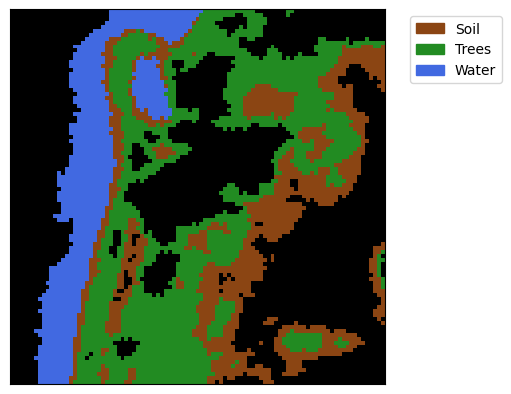

In [7]:
listed_colors = mpl.colors.ListedColormap(colors)

masked_abundances = np.ma.masked_array(
    np.argmax(abundances, axis=0),
    mask=pixel_mask
)

fig,ax = plt.subplots(constrained_layout=True, figsize=(5,5))
ax.matshow(masked_abundances, cmap=listed_colors)
ax.set_facecolor("black")
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.legend(
    handles=[mpl.patches.Patch(color=color, label=label) for color,label in zip(colors,labels)],
    bbox_to_anchor=(1.05, 1), loc=2
)
plt.show()

# Masked Averaged Abundance Map

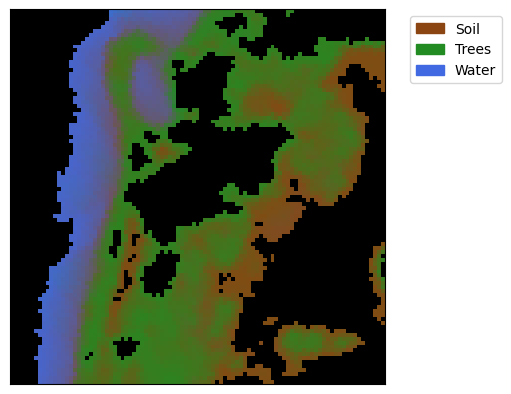

In [8]:
rgb_colors = np.asarray([mpl.colors.to_rgb(color) for color in colors])

abundances_2d = np.reshape(abundances, (len(abundances), -1))
rgb_abundances = np.reshape(
    np.matmul(
        abundances_2d.T, rgb_colors
    ),
    abundances.shape[1:]+(3,)
)
rgb_abundances[pixel_mask] = [0,0,0]

fig,ax = plt.subplots(constrained_layout=True, figsize=(5,5))
ax.matshow(rgb_abundances)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.legend(
    handles=[mpl.patches.Patch(color=color, label=label) for color,label in zip(colors,labels)],
    bbox_to_anchor=(1.05, 1), loc=2
)
plt.show()

# Save Pixel Mask

In [9]:
print(results_basename)
filename = os.path.join(data_dirname, results_basename)
np.savez(filename, pixel_mask=pixel_mask, filter_threshold=filter_threshold)

samson_pixel_mask.npz
